# 智慧农业AI病虫害识别 — 模型训练
## 华为云 ModelArts 一键运行 Notebook

**使用说明：**
1. 在 ModelArts 创建 Notebook 实例（GPU V100 32G）
2. 上传本 Notebook + 项目代码 + 数据集
3. 按顺序执行所有 Cell

**上传后的目录结构：**
```
work/
├── train.ipynb          (本文件)
├── config.yaml
├── knowledge_base.json
├── Data/                (数据集文件夹)
│   ├── AgriculturalDisease_trainingset/
│   └── AgriculturalDisease_validationset/
├── Data/                (代码包)
│   ├── dataset.py
│   └── __init__.py
└── models/
    ├── model.py
    └── __init__.py
```

In [1]:
#!pip install torch torchvision pyyaml tqdm scikit-learn onnx onnxruntime -q

In [2]:
#!pip uninstall torch torchvision -y
#!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
#!pip install pyyaml tqdm scikit-learn onnx onnxruntime -q

In [3]:
# ============================================================
# Cell 1: 环境检查 & 安装依赖
# ============================================================
import sys
print(f"Python: {sys.version}")

# 安装依赖 (CUDA 11.8 版本适配 ModelArts)
#!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118 --quiet
#!pip install pyyaml tqdm scikit-learn onnx onnxruntime --quiet

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
  print(f"GPU: {torch.cuda.get_device_name(0)}")
  print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
  print("[WARN] No GPU. If this is a GPU instance, check driver version.")

Python: 3.9.11 (main, Mar 29 2022, 19:08:29) 
[GCC 7.5.0]
PyTorch: 2.7.1+cu118
CUDA available: True
GPU: Tesla V100-PCIE-32GB
GPU Memory: 31.7 GB


In [4]:
# ============================================================
# Cell 2: 加载配置
# ============================================================
import yaml
import os
from pathlib import Path

# 确保工作目录正确
WORK_DIR = Path(os.getcwd())
print(f"Working directory: {WORK_DIR}")

with open("config.yaml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

print(f"Classes: {cfg['data']['num_classes']}")
print(f"Image size: {cfg['data']['image_size']}")
print(f"Batch size: {cfg['train']['batch_size']}")
print(f"Epochs: {cfg['train']['epochs']}")
print(f"Learning rate: {cfg['train']['learning_rate']}")

# 列出数据目录确认
data_root = Path("./Data")
if data_root.exists():
    print(f"\nData directory OK: {data_root}")
    for d in data_root.iterdir():
        if d.is_dir():
            print(f"  {d.name}/")
else:
    print(f"\n[WARN] Data directory not found: {data_root}")
    print("Please make sure to upload the Data folder!")

Working directory: /home/ma-user/work
Classes: 61
Image size: 224
Batch size: 64
Epochs: 50
Learning rate: 0.0003

Data directory OK: Data
  __pycache__/
  AgriculturalDisease_trainingset/
  AgriculturalDisease_validationset/


In [5]:
# ============================================================
# Cell 3: 加载数据
# ============================================================
import sys
sys.path.insert(0, str(WORK_DIR))

from Data.dataset import get_dataloaders

train_loader, val_loader, label_dist = get_dataloaders(cfg)

print(f"\n--- Data Summary ---")
print(f"Training:   {len(train_loader.dataset)} images, {len(train_loader)} batches")
print(f"Validation: {len(val_loader.dataset)} images, {len(val_loader)} batches")
print(f"Classes:    {len(label_dist)}")
print(f"Class distribution (top 10):")
for cls_id, count in label_dist.most_common(10):
    name = cfg['class_names'].get(cls_id, f'class_{cls_id}')
    print(f"  [{cls_id:2d}] {name:20s} -> {count} images")

# 验证一个batch
images, labels = next(iter(train_loader))
print(f"\nBatch shape: {images.shape}")
print(f"Label range: {labels.min().item()} - {labels.max().item()}")

/home/ma-user/modelarts-dev/modelarts-sdk/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


Loading: ./Data/AgriculturalDisease_trainingset/train_list.txt (type=txt) ...
  Loaded 31541 samples  |  classes: 61
Loading: ./Data/AgriculturalDisease_validationset/AgriculturalDisease_validation_annotations.json (type=json) ...
  [WARN] JSON条目(4540) != 文件数(4534)，按较短的一方配对
  Loaded 4534 samples  |  classes: 60
训练集: 31541张, 61类
验证集: 4534张
类别分布(top5): [(59, 2445), (25, 1824), (26, 1787), (33, 1430), (58, 1338)]

--- Data Summary ---
Training:   31541 images, 492 batches
Validation: 4534 images, 71 batches
Classes:    61
Class distribution (top 10):
  [59] 番茄黄化曲叶病一般            -> 2445 images
  [25] 葡萄霜霉病一般              -> 1824 images
  [26] 葡萄霜霉病严重              -> 1787 images
  [33] 辣椒健康                 -> 1430 images
  [58] 番茄红蜘蛛病严重             -> 1338 images
  [41] 草莓健康                 -> 1208 images
  [ 0] 苹果健康                 -> 1185 images
  [49] 番茄晚疫病一般              -> 1075 images
  [30] 桃健康                  -> 1025 images
  [43] 草莓叶枯病严重              -> 966 images

Batch shape: tor

In [6]:
# ============================================================
# Cell 4: 构建模型
# ============================================================
import torch
import torch.nn as nn
from models.model import CropDiseaseClassifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = CropDiseaseClassifier(
    num_classes=cfg["data"]["num_classes"],
    pretrained=cfg["model"]["pretrained"],
    dropout=cfg["model"]["dropout"],
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params/1e6:.1f}M")
print(f"Trainable params: {trainable_params/1e6:.1f}M")

# 测试前向传播
dummy = torch.randn(4, 3, 224, 224).to(device)
with torch.no_grad():
    out = model(dummy)
print(f"Forward test: {dummy.shape} -> {out.shape} (should be [4, 61])")

Device: cuda
Total params: 23.6M
Trainable params: 23.6M
Forward test: torch.Size([4, 3, 224, 224]) -> torch.Size([4, 61]) (should be [4, 61])


In [7]:
# ============================================================
# Cell 5: 训练配置 (优化器 & 损失函数 & 学习率策略)
# ============================================================
import math
import torch.optim as optim
from torch.amp import autocast, GradScaler

# 损失函数 (Label Smoothing 应对61类细粒度)
criterion = nn.CrossEntropyLoss(
    label_smoothing=cfg["train"].get("label_smoothing", 0.1)
)

# 优化器
optimizer = optim.AdamW(
    model.parameters(),
    lr=cfg["train"]["learning_rate"],
    weight_decay=cfg["train"]["weight_decay"],
)

# 混合精度
use_amp = cfg["train"].get("mixed_precision", True) and device.type == "cuda"
scaler = GradScaler() if use_amp else None
print(f"Mixed Precision (AMP): {use_amp}")

# 学习率调度: Cosine + Warmup
def get_lr(epoch, warmup_epochs=2, total_epochs=30, base_lr=1e-4):
    if epoch < warmup_epochs:
        return base_lr * (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
    return base_lr * 0.5 * (1.0 + math.cos(math.pi * progress))

print(f"Criterion: CrossEntropyLoss(label_smoothing=0.1)")
print(f"Optimizer: AdamW(lr={cfg['train']['learning_rate']}, wd={cfg['train']['weight_decay']})")
print(f"LR Schedule: CosineAnnealing + {cfg['train'].get('warmup_epochs',2)}-epoch Warmup")

Mixed Precision (AMP): True
Criterion: CrossEntropyLoss(label_smoothing=0.1)
Optimizer: AdamW(lr=0.0003, wd=0.0001)
LR Schedule: CosineAnnealing + 2-epoch Warmup


In [8]:
#!pip install ipywidgets -q

In [9]:
# ============================================================
# Cell 6: 训练循环
# ============================================================
import time
import numpy as np
from tqdm import tqdm

Path("checkpoints").mkdir(exist_ok=True)

epochs = cfg["train"]["epochs"]
patience = cfg["train"].get("patience", 8)
best_val_acc = 0.0
best_epoch = 0
no_improve = 0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

# ====== MixUp ======
def mixup(x, y, alpha=0.15):
  if alpha > 0:
      lam = np.random.beta(alpha, alpha)
  else:
      lam = 1
  idx = torch.randperm(x.size(0), device=x.device)
  return lam * x + (1 - lam) * x[idx], y, y[idx], lam

print(f"{'='*60}")
print(f"Start Training: {epochs} epochs, with MixUp")
print(f"{'='*60}\n")

for epoch in range(epochs):
  epoch_start = time.time()

  current_lr = get_lr(
      epoch,
      warmup_epochs=cfg["train"].get("warmup_epochs", 2),
      total_epochs=epochs,
      base_lr=cfg["train"]["learning_rate"],
  )
  for param_group in optimizer.param_groups:
      param_group["lr"] = current_lr

  # ========== Train ==========
  model.train()
  train_loss, train_correct, train_total = 0.0, 0, 0

  pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
  for images, labels in pbar:
      images, labels = images.to(device), labels.to(device)

      # MixUp（前10个epoch使用，之后普通训练）
      if epoch < 20:
          images, targets_a, targets_b, lam = mixup(images, labels)

      optimizer.zero_grad()
      if use_amp:
          with autocast('cuda'):
              outputs = model(images)
              loss = lam * criterion(outputs, targets_a) + (1 - lam) * criterion(outputs, targets_b) if epoch < 20 else criterion(outputs, labels)
          scaler.scale(loss).backward()
          scaler.step(optimizer)
          scaler.update()
      else:
          outputs = model(images)
          loss = lam * criterion(outputs, targets_a) + (1 - lam) * criterion(outputs, targets_b) if epoch < 20 else criterion(outputs, labels)
          loss.backward()
          optimizer.step()

      train_loss += loss.item()
      _, preds = outputs.max(1)
      if epoch < 20:
          train_correct += lam * preds.eq(targets_a).sum().item() + (1 - lam) * preds.eq(targets_b).sum().item()
      else:
          train_correct += preds.eq(labels).sum().item()
      train_total += labels.size(0)

      pbar.set_postfix({"loss": f"{loss.item():.3f}", "acc": f"{100.*train_correct/train_total:.1f}%"})

  train_loss_epoch = train_loss / len(train_loader)
  train_acc_epoch = 100. * train_correct / train_total

  # ========== Val (不 MixUp) ==========
  model.eval()
  val_loss, val_correct, val_total = 0.0, 0, 0
  with torch.no_grad():
      for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          loss = criterion(outputs, labels)
          val_loss += loss.item()
          _, preds = outputs.max(1)
          val_correct += preds.eq(labels).sum().item()
          val_total += labels.size(0)

  val_loss_epoch = val_loss / len(val_loader)
  val_acc_epoch = 100. * val_correct / val_total

  history["train_loss"].append(train_loss_epoch)
  history["train_acc"].append(train_acc_epoch)
  history["val_loss"].append(val_loss_epoch)
  history["val_acc"].append(val_acc_epoch)

  print(f"\n[Epoch {epoch+1}/{epochs}] Time: {time.time()-epoch_start:.0f}s | LR: {current_lr:.6f}")
  print(f"  Train -> Loss: {train_loss_epoch:.4f}  Acc: {train_acc_epoch:.2f}%")
  print(f"  Val   -> Loss: {val_loss_epoch:.4f}  Acc: {val_acc_epoch:.2f}%")

  if val_acc_epoch > best_val_acc:
      best_val_acc, best_epoch, no_improve = val_acc_epoch, epoch+1, 0
      torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                   "optimizer_state_dict": optimizer.state_dict(),
                   "val_acc": val_acc_epoch, "config": cfg}, "checkpoints/best_model.pth")
      print(f"  ** Best model saved! ({val_acc_epoch:.2f}%)")
  else:
      no_improve += 1
      print(f"  No improvement ({no_improve}/{patience})")

  if no_improve >= patience:
      print(f"\nEarly Stop at epoch {epoch+1}")
      break

print(f"\nBest Val Acc: {best_val_acc:.2f}% (Epoch {best_epoch})")

Start Training: 50 epochs, with MixUp



Epoch 1/50 [Val]: 100%|██████████| 71/71 [00:19<00:00,  3.61it/s]



[Epoch 1/50] Time: 141s | LR: 0.000150
  Train -> Loss: 1.9629  Acc: 46.98%
  Val   -> Loss: 1.5823  Acc: 53.46%
  ** Best model saved! (53.46%)


Epoch 2/50 [Val]: 100%|██████████| 71/71 [00:21<00:00,  3.34it/s]



[Epoch 2/50] Time: 146s | LR: 0.000300
  Train -> Loss: 1.8152  Acc: 49.16%
  Val   -> Loss: 1.5913  Acc: 53.35%
  No improvement (1/15)


...


[Epoch 25/50] Time: 142s | LR: 0.000170
  Train -> Loss: 1.0533  Acc: 71.45%
  Val   -> Loss: 1.6574  Acc: 53.37%
  No improvement (8/15)


Epoch 26/50 [Val]: 100%|██████████| 71/71 [00:21<00:00,  3.33it/s]



[Epoch 26/50] Time: 144s | LR: 0.000160
  Train -> Loss: 1.0218  Acc: 73.15%
  Val   -> Loss: 1.6927  Acc: 52.82%
  No improvement (9/15)


Epoch 27/50 [Train]:   8%|▊         | 41/492 [00:10<01:56,  3.87it/s, loss=0.986, acc=76.9%]


KeyboardInterrupt: 

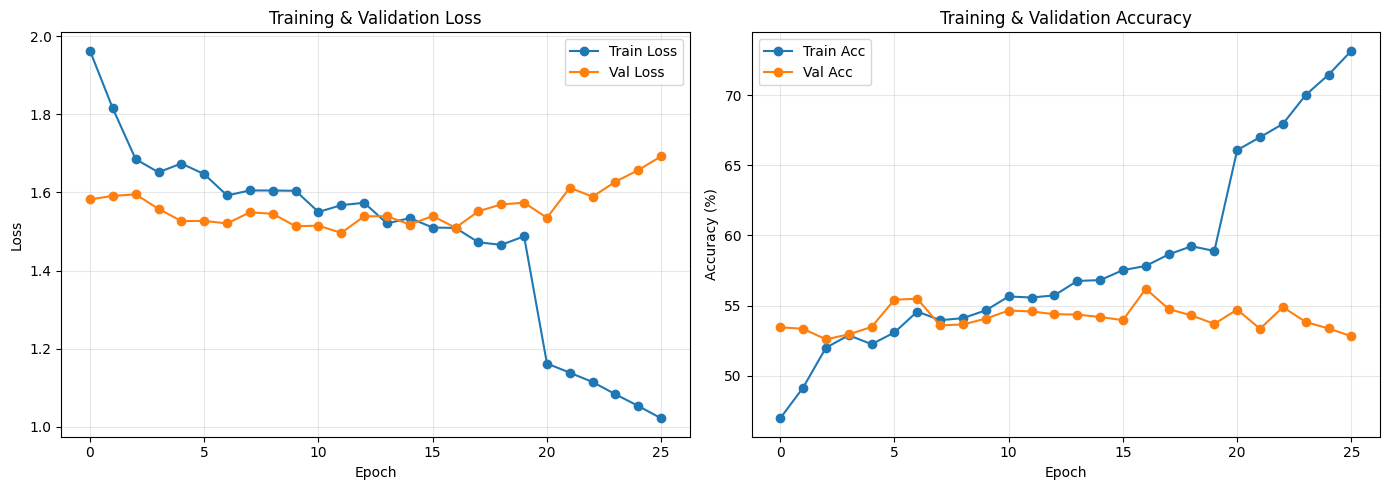

Best validation accuracy: 56.20%


In [10]:
# ============================================================
# Cell 7: 训练曲线可视化
# ============================================================
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss 曲线
ax1.plot(history["train_loss"], label="Train Loss", marker="o")
ax1.plot(history["val_loss"], label="Val Loss", marker="o")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training & Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy 曲线
ax2.plot(history["train_acc"], label="Train Acc", marker="o")
ax2.plot(history["val_acc"], label="Val Acc", marker="o")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Training & Validation Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("checkpoints/training_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Best validation accuracy: {best_val_acc:.2f}%")

In [12]:
# ============================================================
# Cell 8: 模型评估 (纯 PyTorch，不依赖 sklearn)
# ============================================================
import numpy as np
from tqdm import tqdm

# 加载最佳模型
checkpoint = torch.load("checkpoints/best_model.pth", map_location=device, weights_only=True)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Loaded best model (epoch {checkpoint['epoch']+1}, val_acc={checkpoint['val_acc']:.2f}%)")

# 全量预测
all_preds, all_labels = [], []
with torch.no_grad():
  for images, labels in tqdm(val_loader, desc="Evaluating"):
      images = images.to(device)
      outputs = model(images)
      _, preds = outputs.max(1)
      all_preds.extend(preds.cpu().numpy())
      all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# 总体准确率
overall_acc = (all_preds == all_labels).mean()
print(f"\nOverall Accuracy: {overall_acc*100:.2f}% ({all_preds.sum()} correct / {len(all_preds)} total)")

# 手动计算混淆矩阵 & 每类准确率
num_classes = cfg["data"]["num_classes"]
cm = np.zeros((num_classes, num_classes), dtype=np.int64)
for t, p in zip(all_labels, all_preds):
  cm[t, p] += 1

per_class_acc = np.zeros(num_classes)
for i in range(num_classes):
  if cm[i].sum() > 0:
      per_class_acc[i] = cm[i, i] / cm[i].sum()

# Top-5 最佳 & 最差
ranked = np.argsort(per_class_acc)
worst5, best5 = ranked[:5], ranked[-5:][::-1]

print(f"\n--- Top 5 Best Classes ---")
for idx in best5:
  name = cfg["class_names"].get(int(idx), f"class_{idx}")
  print(f"  [{idx:2d}] {name:25s} Acc: {per_class_acc[idx]*100:.1f}%  ({cm[idx].sum()} samples)")

print(f"\n--- Top 5 Worst Classes ---")
for idx in worst5:
  name = cfg["class_names"].get(int(idx), f"class_{idx}")
  print(f"  [{idx:2d}] {name:25s} Acc: {per_class_acc[idx]*100:.1f}%  ({cm[idx].sum()} samples)")

# 最易混淆的10对
np.fill_diagonal(cm, 0)
flat_idx = np.argsort(cm.ravel())[-10:][::-1]
rows, cols = np.unravel_index(flat_idx, cm.shape)
print(f"\n--- Top 10 Confused Pairs ---")
for r, c in zip(rows, cols):
  real = cfg["class_names"].get(int(r), f"class_{r}")
  pred = cfg["class_names"].get(int(c), f"class_{c}")
  print(f"  {real} -> {pred} ({cm[r,c]} times)")

Loaded best model (epoch 17, val_acc=56.20%)


Evaluating: 100%|██████████| 71/71 [00:21<00:00,  3.25it/s]


Overall Accuracy: 56.20% (153720 correct / 4534 total)

--- Top 5 Best Classes ---
  [55] 番茄斑枯病一般                   Acc: 96.5%  (115 samples)
  [59] 番茄黄化曲叶病一般                 Acc: 87.5%  (353 samples)
  [41] 草莓健康                      Acc: 83.8%  (173 samples)
  [15] 玉米叶斑病一般                   Acc: 83.1%  (71 samples)
  [38] 马铃薯早疫病严重                  Acc: 82.8%  (29 samples)

--- Top 5 Worst Classes ---
  [ 1] 苹果黑星病一般                   Acc: 0.0%  (30 samples)
  [ 2] 苹果黑星病严重                   Acc: 0.0%  (22 samples)
  [ 5] 苹果雪松锈病一般                  Acc: 0.0%  (6 samples)
  [ 4] 苹果灰斑病严重                   Acc: 0.0%  (20 samples)
  [ 7] 樱桃健康                      Acc: 0.0%  (12 samples)

--- Top 10 Confused Pairs ---
  苹果健康 -> 桃健康 (87 times)
  葡萄霜霉病一般 -> 葡萄霜霉病严重 (69 times)
  马铃薯晚疫病严重 -> 玉米叶斑病严重 (65 times)
  番茄晚疫病一般 -> 玉米叶斑病严重 (64 times)
  柑桔黄龙病一般 -> 柑桔黄龙病严重 (52 times)
  苹果灰斑病一般 -> 桃健康 (40 times)
  马铃薯早疫病一般 -> 草莓健康 (40 times)
  番茄斑点病严重 -> 番茄斑枯病一般 (39 times)
  苹果健康 -> 柑桔黄龙病严重 (38 times)
  番茄黄化

In [14]:
# ============================================================
# Cell 9: 导出 ONNX (本地推理用)
# ============================================================
model.eval()
model.cpu()  # ONNX 导出用 CPU

dummy_input = torch.randn(1, 3, 224, 224)

torch.onnx.export(
    model,
    dummy_input,
    "checkpoints/model.onnx",
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"}
    },
    opset_version=12,
    do_constant_folding=True,
)
print("ONNX model exported: checkpoints/model.onnx")

# 验证 ONNX
import onnx
onnx_model = onnx.load("checkpoints/model.onnx")
onnx.checker.check_model(onnx_model)
print("ONNX model validation: PASSED")

import os
size_mb = os.path.getsize("checkpoints/model.onnx") / 1024**2
print(f"ONNX model size: {size_mb:.1f} MB")

ONNX model exported: checkpoints/model.onnx
ONNX model validation: PASSED
ONNX model size: 90.1 MB


Test image: 27_1390.jpg

--- Recognition Results ---
  1. 葡萄黑腐病严重                   95.35% ██████████████████████████████████████
  2. 葡萄轮斑病一般                   1.53% 
  3. 辣椒健康                      1.45% 
  4. 番茄黄化曲叶病一般                 0.15% 
  5. 番茄红蜘蛛病严重                  0.13% 


/home/ma-user/anaconda3/envs/python-3.9.11/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 33889 (\N{CJK UNIFIED IDEOGRAPH-8461}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ma-user/anaconda3/envs/python-3.9.11/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 33796 (\N{CJK UNIFIED IDEOGRAPH-8404}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ma-user/anaconda3/envs/python-3.9.11/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 40657 (\N{CJK UNIFIED IDEOGRAPH-9ED1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ma-user/anaconda3/envs/python-3.9.11/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 33104 (\N{CJK UNIFIED IDEOGRAPH-8150}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


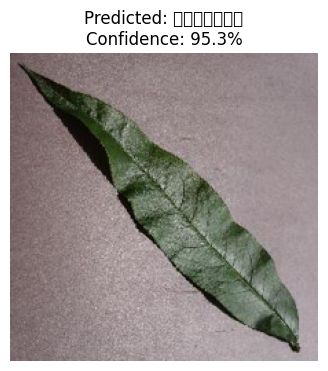

In [21]:
# ============================================================
# Cell 10: 快速推理演示
# ============================================================
import numpy as np
from PIL import Image
import onnxruntime as ort

import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']

# 加载 ONNX 模型
session = ort.InferenceSession("checkpoints/model.onnx", 
                                providers=["CPUExecutionProvider"])
input_name = session.get_inputs()[0].name

# 随机选一张验证集图片
import random
val_images = list(Path("./Data/AgriculturalDisease_validationset/images").glob("*.jpg")) + \
             list(Path("./Data/AgriculturalDisease_validationset/images").glob("*.JPG"))
test_img = random.choice(val_images)
print(f"Test image: {test_img.name}")

# 预处理
image = Image.open(test_img).convert("RGB")
display_img = image.resize((224, 224))
image_np = np.array(image.resize((224, 224)), dtype=np.float32) / 255.0
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
image_np = (image_np - mean) / std
image_np = image_np.transpose(2, 0, 1)[np.newaxis, ...].astype(np.float32)

# 推理
output = session.run(None, {input_name: image_np})[0][0]
probs = np.exp(output - output.max()) / np.exp(output - output.max()).sum()

# Top-5 结果
top5_idx = np.argsort(probs)[::-1][:5]
print(f"\n--- Recognition Results ---")
for rank, idx in enumerate(top5_idx):
    disease_name = cfg["class_names"].get(int(idx), f"class_{idx}")
    conf = probs[idx]
    bar = "█" * int(conf * 40)
    print(f"  {rank+1}. {disease_name:25s} {conf:.2%} {bar}")

# 显示图片
plt.figure(figsize=(4, 4))
plt.imshow(display_img)
plt.title(f"Predicted: {cfg['class_names'].get(int(top5_idx[0]), '?')}\n"
          f"Confidence: {probs[top5_idx[0]]:.1%}")
plt.axis("off")
plt.show()

In [22]:
# ============================================================
# Cell 11: 下载模型文件 (从 ModelArts 下载到本地)
# ============================================================
print("训练产出文件：")
print("="*60)
import os
for f in Path("checkpoints").iterdir():
    size = os.path.getsize(f) / 1024**2 if f.is_file() else 0
    print(f"  {f.name:40s} {size:8.1f} MB")

print()
print("请下载以下文件到本地：")
print("  1. checkpoints/best_model.pth   -> PyTorch 模型")
print("  2. checkpoints/model.onnx      -> ONNX 推理模型")
print("  3. checkpoints/training_curve.png -> 训练曲线图")

训练产出文件：
  best_model.pth                              270.9 MB
  model.onnx                                   90.1 MB
  training_curve.png                            0.1 MB

请下载以下文件到本地：
  1. checkpoints/best_model.pth   -> PyTorch 模型
  2. checkpoints/model.onnx      -> ONNX 推理模型
  3. checkpoints/training_curve.png -> 训练曲线图


In [23]:
import os
os.chdir("checkpoints")
!zip -r /home/ma-user/work/model_output.zip best_model.pth model.onnx training_curve.png
os.chdir("..")
print("Done. Download: model_output.zip")

  adding: best_model.pth (deflated 8%)
  adding: model.onnx (deflated 7%)
  adding: training_curve.png (deflated 9%)
Done. Download: model_output.zip


In [24]:
import moxing as mox

mox.file.copy("checkpoints/best_model.pth", "obs://hwstai/output/best_model.pth")
mox.file.copy("checkpoints/model.onnx", "obs://hwstai/output/model.onnx")
print("Done! Go to OBS -> hwstai -> output/ to download.")


/home/ma-user/anaconda3/envs/python-3.9.11/lib/python3.9/site-packages/moxing/framework/version.py:24: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
INFO:root:Using MoXing-v2.3.11-8a68d29b
INFO:root:Using OBS-Python-SDK-3.26.2
INFO:root:Using OBS-C-SDK-2.23.1


Done! Go to OBS -> hwstai -> output/ to download.
